# Fase 1 - *Ex Ante*

## 1 - Coleta e tratamento dos dados

In [241]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

In [242]:
markers = pd.read_csv("./data/marcacoes.csv")
proxies = pd.read_csv("./data/proxies.csv")

markers['data'] = pd.to_datetime(markers['data'])
proxies['data'] = pd.to_datetime(proxies['data'])

markers = markers.set_index("data").sort_index()
proxies = proxies.set_index("data").sort_index()

proxies.head()

,OLEO3,FUEL3
data,,
2021-06-30,5.80,4.50
2021-07-01,5.60,4.53
2021-07-02,5.65,4.68
2021-07-05,5.65,4.87
2021-07-06,5.86,4.72


### Analisando as séries

Podemos observar em ambos os casos que temos séries não estacionárias (i.e. média e variância não são constantes). Para operar melhor com essas séries, o ideal é criarmos uma versão normalizada dos dados.


### Obtendo o retorno médio normalizado

A partir da premissa de utilizar pesos iguais para os retornos de `OLEO3` e `FUEL3`, vamos calcular o retorno simples (variação percentual de cada proxy), calcularemos a média aritmética entre eles e aplicaremos o logaritmo, conforme o proceso abaixo:

$$
\forall t \text{  Retorno Simples }:= R_t^{(proxy)} = \frac{p_t^{(proxy)} - p_{t-1}^{(proxy)}}{p_{t-1}^{(proxy)}}
$$

Observe nos gráficos abaixo com o retorno já apresenta as propriedades de estacionaridade como gostaríamos.
Depois, calculamos a média e aplicamos o logaritmo

$$
\Rightarrow r_t = \ln \left( 1 + \frac{R_t^{(OLEO3)} + R_t^{(FUEL3)}}{2} \right)
$$

O logaritmo garante a aditividade temporal na série, que será útil nas próximas análises

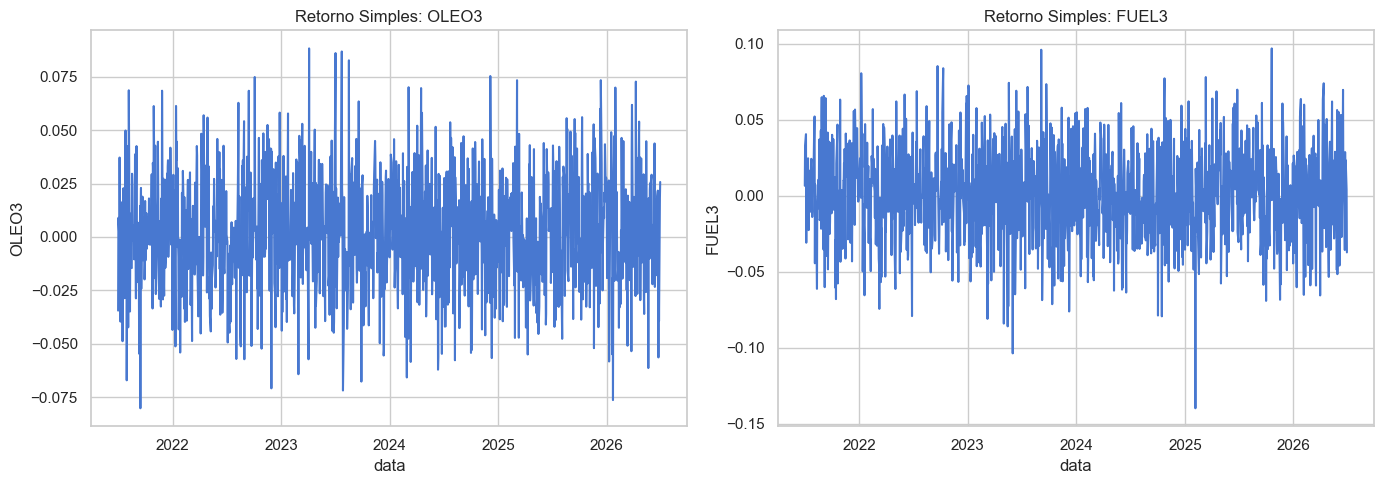

In [243]:
simple_returns = proxies.pct_change().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.lineplot(data=simple_returns['OLEO3'], ax=axes[0])
axes[0].set_title('Retorno Simples: OLEO3')

sns.lineplot(data=simple_returns['FUEL3'], ax=axes[1])
axes[1].set_title('Retorno Simples: FUEL3')

plt.tight_layout()
plt.show()

# Calculando a média e obtendo o logaritmo

retorno_medio_simples = simple_returns.mean(axis=1)
log_returns = pd.DataFrame(
    np.log(1 + retorno_medio_simples),
    columns=['MEAN'],
    index=simple_returns.index
)

Podemos observar as a distribuição do log-retorno

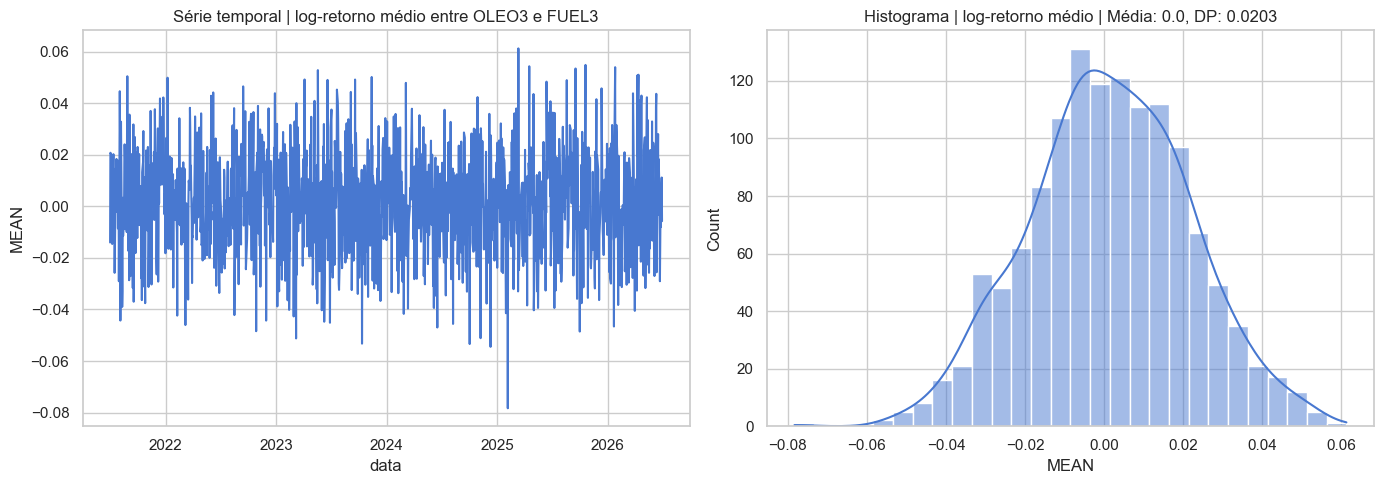

In [244]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.lineplot(data=log_returns['MEAN'], ax=axes[0])
axes[0].set_title('Série temporal | log-retorno médio entre OLEO3 e FUEL3')

sns.histplot(data=log_returns['MEAN'], ax=axes[1], kde=True)
axes[1].set_title(f'Histograma | log-retorno médio | Média: {log_returns['MEAN'].mean():.1f}, DP: {log_returns['MEAN'].std():.4f}')
plt.tight_layout()
plt.show()



### Visualização das Séries

Comparando o histórico das marcações com o retorno logarítmico da carteira sintética.

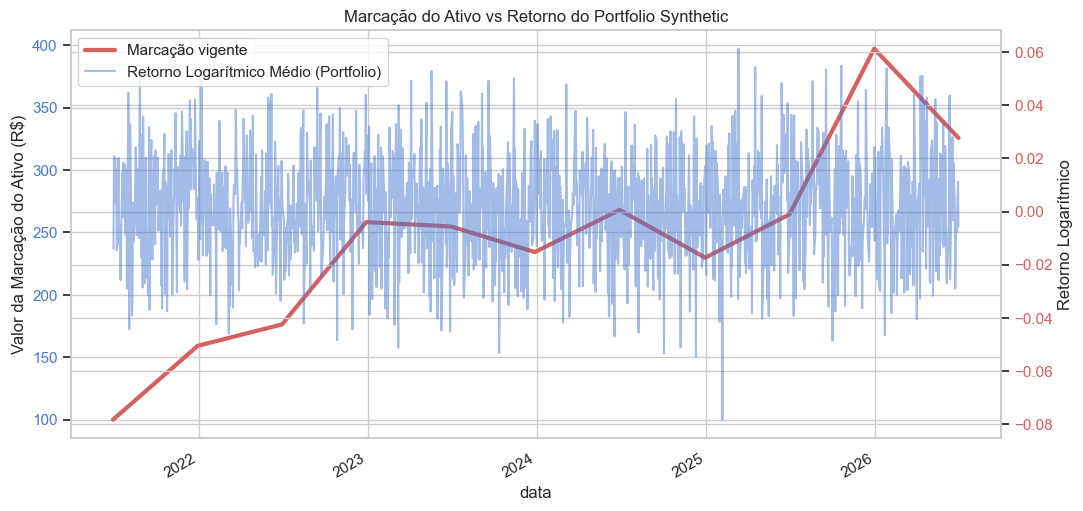

In [245]:
fig, ax1 = plt.subplots(figsize=(12,6))

sns.lineplot(data=markers, x=markers.index, y="valor", label="Marcação vigente", ax=ax1, linewidth=3, color='r')
ax1.set_ylabel('Valor da Marcação do Ativo (R$)')
ax1.tick_params(axis='y', labelcolor='b')

ax2 = ax1.twinx()
sns.lineplot(data=log_returns, x=log_returns.index, y="MEAN", label="Retorno Logarítmico Médio (Portfolio)", ax=ax2, alpha=0.5)
ax2.set_ylabel('Retorno Logarítmico')
ax2.tick_params(axis='y', labelcolor='r')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

fig.autofmt_xdate()

plt.title('Marcação do Ativo vs Retorno do Portfolio Synthetic')
plt.show()

## 2 - Modelagem para gerar as estimativas pontuais



### Selecionando dados de interesse

Afinal, queremos saber dos valores após a marcação `M10`, então vamos trabalhar com esses dados somente.

In [246]:
max_date = markers.index.max()
date_m10 = markers[markers['marcacao'] == 'M10'].index[0]
value_m10 = markers.loc[date_m10, 'valor']
max_date = markers.index.max()

post_m10_log_returns = log_returns.loc[date_m10:]

# Garantir que a variação acumulada no dia do lançamento de M10 seja nula
post_m10_log_returns.loc[date_m10, 'MEAN'] = 0

### Obtendo o log-retorno acumulado

Partindo do pressuposto que os log-retornos são aditivos, podemos obter o retorno total acumulado desde o lançamento de `M10` para todos os dias até o lançamento de `M11`:

In [247]:

cumsum_log_return = post_m10_log_returns.cumsum()


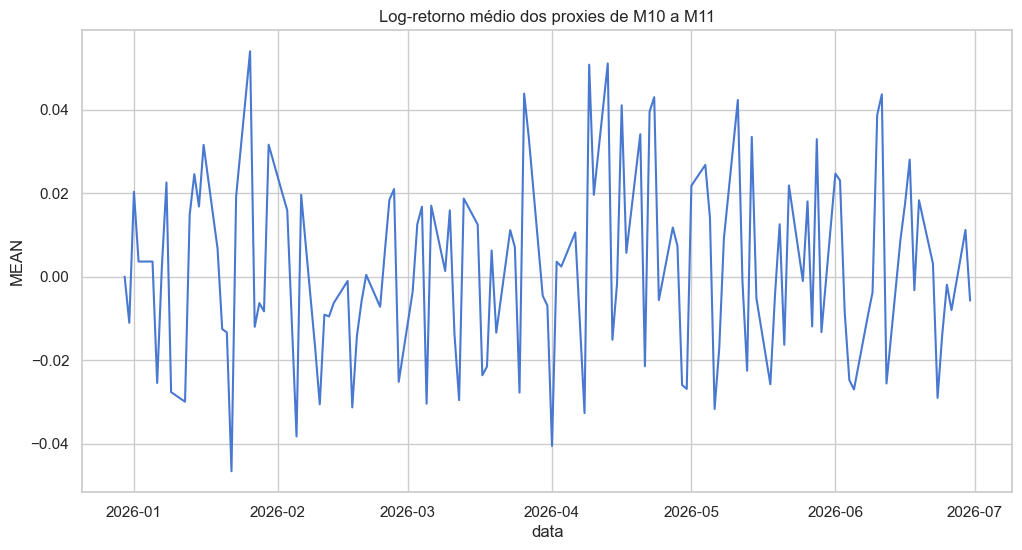

In [248]:
plt.figure(figsize=(12,6))
sns.lineplot(post_m10_log_returns['MEAN'])
plt.title('Log-retorno médio dos proxies de M10 a M11')
plt.show()

### Obtendo as previsões para os marcadores

A partir da fórmula abaixo, calculamos os valores previstos para o marcador nas datas intermediárias até o lançamento de `M11`:

$$
\hat{M_t} = M_{10} \cdot e^{(\sum_{i=T_{M_{10}}}^t r_{i})}
$$

Em que $\hat{M_t}$ é a estimativa de preço para toda data $t$ entre $T_{M_{10}}$ e $T_{M_{11}}$. Note que $r_i$ é o log-retorno médio dos proxies.

In [249]:

marker_estimates = value_m10 * np.exp(cumsum_log_return)
marker_estimates.columns = ['MARKER_ESTIMATE']


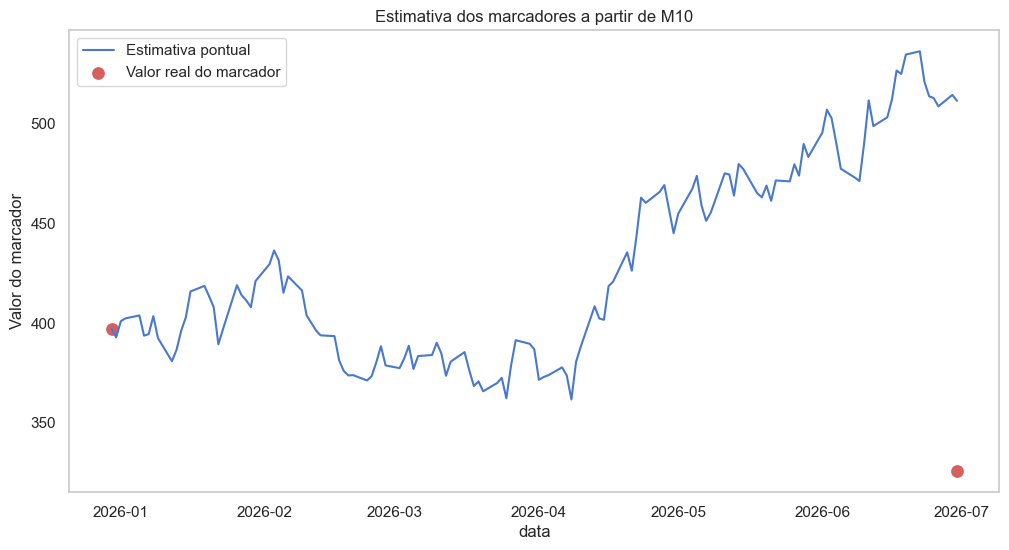

In [250]:

plt.figure(figsize=(12,6))
sns.lineplot(data=marker_estimates, x='data', y='MARKER_ESTIMATE', color='b', label='Estimativa pontual')
sns.scatterplot(data=markers.loc[date_m10:], x='data', y='valor', color='r', label='Valor real do marcador', s=100)
plt.ylabel('Valor do marcador')
plt.title('Estimativa dos marcadores a partir de M10')
plt.grid(False)
plt.show()

### Criando a função para estimação pontual

Agora, com as previsões feitas, basta definir uma função única que retorne uma estimativa pontual a partir de uma data inserida.

O método recebe o dia, mês e ano - adaptando para o formato de data e validando eventuais inconsitências nos dados. Também verifica se a data está dentro do intervalo de interesse.

Note que, como os valores das proxys são registradas apenas em dias úteis, utilizamos a função `asof` do Pandas que nos permite retornar o valor da data mais próxima da inserida (caso ela seja em um final de semana, por exemplo).

In [251]:

def return_marker_estimate(day:int, month:int, year:int)-> str:

    if not isinstance(day, int) or not isinstance(month, int) or not isinstance(year, int):
        return "Insira valores válidos para dia, mês ou ano"

    date = pd.to_datetime(f"{year}-{month:02d}-{day:02d}")

    if date < marker_estimates.index.min() or date > marker_estimates.index.max():
        return "Insira uma data após o lançamento de M10 até o dia do lançamento de M11"

    closest_estimate = float(marker_estimates['MARKER_ESTIMATE'].asof(date))

    return f"Valor estimado para {date.strftime('%d/%m/%Y')} : R$ {closest_estimate:.2f}"


## Sinta-se à vontade para testar a função aqui!

In [252]:
day = 19
month = 4
year = 2026

return_marker_estimate(day, month, year)


'Valor estimado para 19/04/2026 : R$ 420.81'